In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go

In [2]:
SteamData = pd.read_csv('./csv/steam.csv')
SteamData.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
SteamData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
SteamData.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [ ]:


# 1. Generamos los dummies (¡Mantenemos el sep=';' por seguridad!)
dict_imagenes = SteamData.set_index('name')['appid'].to_dict()
genres_dummies = SteamData['genres'].str.get_dummies(sep=';')
categories_dummies = SteamData['categories'].str.get_dummies(sep=';')
tags_dummies = SteamData['steamspy_tags'].str.get_dummies(sep=';')

# 2. Concatenamos todo en un DataFrame temporal
SteamDataCompleto = pd.concat([SteamData, genres_dummies, categories_dummies, tags_dummies], axis=1)

# 3. Limpieza de duplicados
SteamDataCompleto = SteamDataCompleto.drop_duplicates(subset=['name'], keep='first')

# --- PASO EXTRA: Ingeniería de Variables (Para que sea inteligente) ---
# Creamos un 'score' de 0 a 1 basado en las valoraciones
SteamDataCompleto['calidad_score'] = SteamDataCompleto['positive_ratings'] / (SteamDataCompleto['positive_ratings'] + SteamDataCompleto['negative_ratings'] + 1)

# Usamos MinMaxScaler para el precio y el score para que estén en la misma escala (0 a 1) que los dummies
scaler_geo = MinMaxScaler()
SteamDataCompleto[['price', 'calidad_score']] = scaler_geo.fit_transform(SteamDataCompleto[['price', 'calidad_score']])

# 4. Definimos las columnas que REALMENTE sobran (Solo texto y IDs)
# NOTA: NO incluimos 'price' ni 'calidad_score' aquí porque queremos que el modelo las use
columnas_a_eliminar = [
    'appid', 'release_date', 'english', 'developer', 'publisher', 
    'platforms', 'required_age', 'achievements', 'median_playtime', 
    'owners', 'genres', 'categories', 'steamspy_tags',
    'positive_ratings', 'negative_ratings', 'average_playtime'
]

# 5. Creamos el DataFrame Final
SteamDataFinal = SteamDataCompleto.drop(columnas_a_eliminar, axis=1)

# 6. Set Index
SteamDataFinal.set_index('name', inplace=True)

# 7. IMPORTANTE: Si alguna fila quedó con NaN (por el score), la llenamos con 0
SteamDataFinal = SteamDataFinal.fillna(0)

print(f"✅ Dataset listo. Forma final: {SteamDataFinal.shape}")
print(f"Muestra de columnas: {SteamDataFinal.columns.tolist()[:5]} ... [price] ... [calidad_score]")
SteamDataFinal.head()

✅ Dataset listo. Forma final: (27033, 399)
Muestra de columnas: ['price', 'Accounting', 'Action', 'Adventure', 'Animation & Modeling'] ... [price] ... [calidad_score]


,price,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,...,Web Publishing,Werewolves,Western,Word Game,World War I,World War II,Wrestling,Zombies,e-sports,calidad_score
name,,,,,,,,,,,,,,,,,,,,,
Counter-Strike,0.017038,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.979488
Team Fortress Classic,0.009455,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.844409
Day of Defeat,0.009455,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.900569
Deathmatch Classic,0.009455,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.830844
Half-Life: Opposing Force,0.009455,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.953282


In [6]:

scaler = StandardScaler()

data_scaled = scaler.fit_transform(SteamDataFinal)

pca = PCA(n_components=350)
data_pca = pca.fit_transform(data_scaled)

print(f"Varianza explicada total: {pca.explained_variance_ratio_.sum()}")

Varianza explicada total: 0.9626426484106543


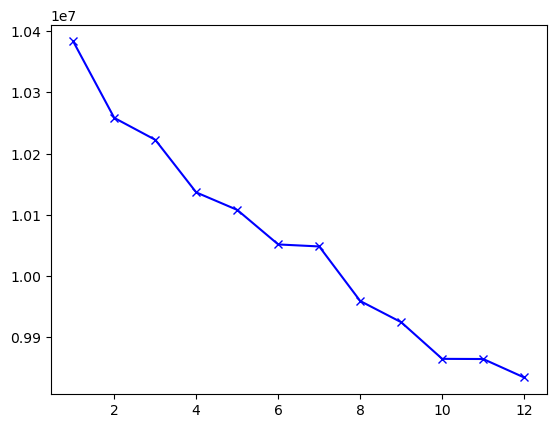

In [7]:
inertias = []
rango_k = range(1, 13) 

for i in rango_k:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)

    kmeans.fit(data_pca)
    
    inertias.append(kmeans.inertia_)
    
plt.plot(rango_k, inertias, 'bx-')

In [8]:

pipeline_clustering = make_pipeline(
    StandardScaler(),
    PCA(n_components=350),
    KMeans(n_clusters=150, random_state=42)
)

pipeline_clustering.fit(SteamDataFinal)

clusters = pipeline_clustering.named_steps['kmeans'].labels_


In [9]:

SteamDataFinal['cluster'] = clusters

print(SteamDataFinal[SteamDataFinal['cluster'] == 0].mean().sort_values(ascending=False).head(10))

Racing                0.998619
Racing                0.991713
Single-player         0.959945
calidad_score         0.633568
Indie                 0.582873
Steam Achievements    0.488950
Indie                 0.459945
Action                0.421271
Multi-player          0.368785
Action                0.357735
dtype: float64


In [10]:
# Cambia el 3 por cualquier número de cluster que hayas obtenido (0 al 7)
juegos_del_grupo = SteamDataFinal[SteamDataFinal['cluster'] == 0].index
print(SteamDataFinal['cluster'].value_counts())

cluster
91     3545
43     3180
125    2552
1      2066
11     1890
       ... 
42        1
44        1
46        1
106       1
2         1
Name: count, Length: 150, dtype: int64


In [11]:
# Cambia el 21 por cualquier cluster que te de curiosidad
print(SteamDataFinal[SteamDataFinal['cluster'] == 0].index[:20])

Index(['FlatOut 2™', 'Xpand Rally', 'RACE - The WTCC Game',
       'RACE: Caterham Expansion', 'FlatOut', 'Ducati World Championship',
       'Trackmania United Forever Star Edition', 'Death Track®: Resurrection',
       'RACE 07', 'GTR 2 FIA GT Racing Game', 'TrackMania Nations Forever',
       'Gumboy Tournament', 'FlatOut: Ultimate Carnage',
       '18 Wheels of Steel: American Long Haul',
       'Sprint Cars Road to Knoxville', 'Midnight Outlaw: 6 Hours to SunUp',
       'Trials 2: Second Edition', 'Monster Trucks Nitro ',
       'Need for Speed Undercover', 'Zero Gear'],
      dtype='object', name='name')


In [12]:
# 1. Extraemos los datos transformados (quitando la columna 'cluster' para que no de error)
# Usamos .drop(columns=['cluster']) para que los nombres de las columnas coincidan exactamente
data_pca_real = pipeline_clustering.named_steps['pca'].transform(
    pipeline_clustering.named_steps['standardscaler'].transform(SteamDataFinal.drop(columns=['cluster']))
)

# 2. Entrenamos el buscador con esos 300 datos
# Cambia esto en tu sección del buscador en Jupyter:
buscador = NearestNeighbors(n_neighbors=6, metric='cosine') # <--- Cambia a cosine
buscador.fit(data_pca_real)

# 3. Función para recomendar
def recomendar(nombre_juego):
    idx = SteamDataFinal.index.get_loc(nombre_juego)
    distancias, indices = buscador.kneighbors([data_pca_real[idx]])
    return SteamDataFinal.index[indices[0][1:]]

# 4. Prueba de fuego
print(recomendar('Counter-Strike'))

Index(['Team Fortress Classic', 'Deathmatch Classic', 'Ricochet',
       'Half-Life Deathmatch: Source', 'Counter-Strike: Condition Zero'],
      dtype='object', name='name')


In [13]:

# 1. Primero, eliminamos duplicados en el índice para evitar el error
# Esto mantiene solo la primera aparición de cada juego
SteamDataFinal = SteamDataFinal[~SteamDataFinal.index.duplicated(keep='first')]

# 2. Ahora sí, ejecutamos el PCA 3D
pca_3d = PCA(n_components=3)
data_3d = pca_3d.fit_transform(data_scaled) # Asegúrate que data_scaled tenga el mismo número de filas que SteamDataFinal ahora

# 3. Creamos el DataFrame de visualización
df_visualizacion = pd.DataFrame(data=data_3d, columns=['PC1', 'PC2', 'PC3'])

# OJO AQUÍ: Como reseteamos SteamDataFinal, lo mejor es usar .values 
# para que no intente comparar los índices de nuevo
df_visualizacion['Juego'] = SteamDataFinal.index
df_visualizacion['Cluster'] = SteamDataFinal['cluster'].values # .values evita el error de reindexación

# 4. Y ahora el gráfico (el resto del código de 'go' igual que antes)

# 3. Creamos la figura con Graph Objects
fig = go.Figure(data=[go.Scatter3d(
    x=df_visualizacion['PC1'],
    y=df_visualizacion['PC2'],
    z=df_visualizacion['PC3'],
    mode='markers',
    marker=dict(
        size=2,                  # Puntos pequeños para que no se amontonen (son 27k juegos)
        color=df_visualizacion['Cluster'], # El color varía según el cluster
        colorscale='Viridis',    # Una escala de colores profesional
        opacity=0.6              # Un poco de transparencia para ver la densidad
    ),
    text=df_visualizacion['Juego'], # El nombre que aparecerá al pasar el cursor
    hoverinfo='text'
)])

# 4. Personalización del diseño (Layout)
fig.update_layout(
    title='Visualización 3D de Clusters de Videojuegos',
    scene=dict(
        xaxis=dict(title='PC 1 (Estilo)'),
        yaxis=dict(title='PC 2 (Mecánicas)'),
        zaxis=dict(title='PC 3 (Popularidad/Otros)')
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Aprovechar todo el espacio
)

# 5. Mostrar
fig.show()

In [14]:
import joblib

# Supongamos que X_train es tu matriz de etiquetas (antes del PCA)
# y que 'pipeline_clustering' es el que tiene el PCA(n_components=300)

# RE-ENTRENA EL PIPELINE PARA ESTAR SEGUROS (Opcional pero recomendado)
# pipeline_clustering.fit(X_train) 

# 1. Guardar el pipeline (que transforma de 397 a 300)
joblib.dump(pipeline_clustering, './modelo/pipeline_steam.joblib')

# 2. Guardar el buscador KNN (que espera 300)
# ¡IMPORTANTE! Asegúrate de que el buscador se entrenó con el resultado del pipeline
# X_pca = pipeline_clustering.transform(X_train)
# buscador.fit(X_pca)
joblib.dump(buscador, './modelo/modelo_recomendador.joblib')

# 3. Guardar los datos para la App
SteamDataFinal.to_pickle('./modelo/datos_steam_con_clusters.pkl')

print("Fase 1 completada. El pipeline exportado transforma a 300 componentes.")

Fase 1 completada. El pipeline exportado transforma a 300 componentes.


In [15]:
# Lista de juegos a comparar
juegos_comparar = [
    'Undertale', 
    'Life is Strange - Episode 1', 
    'Life is Strange: Before the Storm', 
    'It\'s You: A Breakup Story', 
    'Hero-U: Rogue to Redemption', 
    'Tyranny'
]

# Filtramos el DataFrame para estos juegos
df_comparativa = SteamDataFinal.loc[juegos_comparar]

# Para cada juego recomendado, veamos qué etiquetas COMPARTE con Undertale
undertale_tags = set(df_comparativa.columns[(df_comparativa.loc['Undertale'] == 1)])

for juego in juegos_comparar[1:]:
    juego_tags = set(df_comparativa.columns[(df_comparativa.loc[juego] == 1)])
    comunes = undertale_tags.intersection(juego_tags)
    
    print(f"--- {juego} ---")
    print(f"Coincidencias ({len(comunes)}): {list(comunes)[:10]}...") # Mostramos las primeras 10
    print(f"Etiquetas que NO tiene Undertale: {list(juego_tags - undertale_tags)[:5]}\n")

--- Life is Strange - Episode 1 ---
Coincidencias (5): ['Story Rich', 'Single-player', 'Choices Matter', 'Steam Trading Cards', 'Great Soundtrack']...
Etiquetas que NO tiene Undertale: ['Steam Cloud', 'Steam Achievements', 'Action', 'Adventure', 'Full controller support']

--- Life is Strange: Before the Storm ---
Coincidencias (5): ['Story Rich', 'Single-player', 'Choices Matter', 'Steam Trading Cards', 'Great Soundtrack']...
Etiquetas que NO tiene Undertale: ['Steam Cloud', 'Steam Achievements', 'Action', 'Adventure', 'Full controller support']

--- It's You: A Breakup Story ---
Coincidencias (4): ['Indie', 'Single-player', 'Choices Matter', 'Story Rich']...
Etiquetas que NO tiene Undertale: []

--- Hero-U: Rogue to Redemption ---
Coincidencias (4): ['Story Rich', 'Choices Matter', 'RPG', 'Single-player']...
Etiquetas que NO tiene Undertale: ['Steam Achievements', 'Adventure']

--- Tyranny ---
Coincidencias (5): ['Story Rich', 'Single-player', 'Choices Matter', 'Steam Trading Cards',